# Reflection on ODD

<div style="text-align: justify">

Notebook used to perform ODD checks on the input train data & metadata. Exploration of monitoring approaches and properties to check in relation to the ODD.

First part of the notebook is independent of any ML model training (focus on input metadata) while the second part of the notebook is based on the ML model prediction (bounding box) being coherent with the autorised/plausible positions of the GLAC in an image.
</div>

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from pathlib import Path
from typing import Dict, List, Union

import pandas as pd
import numpy as np
import torch
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from swmf.data import create_dataloader

In [47]:
PATH_TO_EXPORTED_LARD = "../data/datasets/lard_512x512_ICPR2026"


lard_data_dpath = Path(PATH_TO_EXPORTED_LARD).resolve()
split_fpath = lard_data_dpath / "split_trainval_per_runway.csv"
split_dname = split_fpath.stem

print("Root path to lard exported data:", lard_data_dpath.as_posix())
print("Path to train split description:", split_fpath.as_posix())
print("Name of the split strategy directory:", split_dname)

Root path to lard exported data: /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026
Path to train split description: /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/split_trainval_per_runway.csv
Name of the split strategy directory: split_trainval_per_runway


Define dataloaders for the ML `detect` task, for the `train`, `valid` and `test` splits.

In [48]:
# Constant variable to handle the different shapes of the ML task labels
ML_LABEL_SHAPE = {
    "segment": (1, 9),
    "detect" : (1, 5),
}

In [49]:
train_dataloader = create_dataloader(
    dataset_dpath=lard_data_dpath,
    yolo_task="detect",
    data_mode="train",
    using_split=True,
    split_fpath=split_fpath,
    split="train",
    using_metadata=True,
    batch_size=64,
    shuffle=False,
)

valid_dataloader = create_dataloader(
    dataset_dpath=lard_data_dpath,
    yolo_task="detect",
    data_mode="train",
    using_split=True,
    split_fpath=split_fpath,
    split="valid",
    using_metadata=True,
    batch_size=4,
    shuffle=False,
)

test_dataloader = create_dataloader(
    dataset_dpath=lard_data_dpath,
    yolo_task="detect",
    data_mode="test",
    using_metadata=True,
    batch_size=4,
    shuffle=False,
)

Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/train
Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/train
Path to metadata not provided, trying to infer based on dataset path...
Found existing metadata at /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/task_detect/metadatas/test


In [50]:
train_seg_dataloader = create_dataloader(
    dataset_dpath=lard_data_dpath,
    yolo_task="segment",
    data_mode="train",
    using_split=True,
    split_fpath=split_fpath,
    split="train",
    using_metadata=False,
    batch_size=64,
    shuffle=False,
)

## ODD conformity

### Verifying the *Generic Landing Approach Cone*

<div style="text-align: justify">

The ranges of values for the 6-parameter *generic landing approach cone* (GLAC), as described in the (Ducoffe et al, 2023), are the following:

| Parameter                | Range         | Units |
|--------------------------|:-------------:|:-----:|
| ATD                      | [ 0.08,  3]   | NM (nautical miles)  |
| VPA                      | [-2.2 , -3.8] | degrees |
| LPA                      | [-4   ,  4]   | degrees |
| $\phi$ (*roll angle*)    | [-10  ,  10]  | degrees |
| $\theta$ (*pitch angle*) | [-8   ,  0]   | degrees |
| $\psi$ (*yaw angle*)     | [-10  ,  10]  | degrees |

The actual ranges as they are provided in the metadata files (the `*.csv` files) are slightly different:

- The `VPA` parameter is always positive instead of negative $\rightarrow$ new range $[2.2, 3.8]$.

- The *pitch angle* $\theta$ is 90° at horizontal instead of 0° (rotation by 90°).

- The *yaw angle* $\psi$ is absolute (wrt to North-South direction) instead of relative to the runway bearing angle. 

However, these modifications are already treated in the data export phase ([`data-export.ipynb`](./data-export.ipynb) notebook). So the information we get on the image position and attitude are coherence with the *Generic Landing Approach Cone* description made in (Ducoffe et al, 2023).
</div>

In [51]:
# Generic landing approach cone definition
GLAC = {
    'ATD': np.array([0.08, 3]),     # NM
    'VPA': np.array([-2.2, -3.8]),  # °
    'LPA': np.array([-4, 4]),       # °
    'phi': np.array([-10, 10]),     # °
    'theta': np.array([-8, 0]),     # °
    'psi': np.array([-10, 10]),     # °
}

print("Generic Landing Approach Cone:")
GLAC

Generic Landing Approach Cone:


{'ATD': array([0.08, 3.  ]),
 'VPA': array([-2.2, -3.8]),
 'LPA': array([-4,  4]),
 'phi': array([-10,  10]),
 'theta': array([-8,  0]),
 'psi': array([-10,  10])}

In [52]:
# Generic landing approach cone conversion to SI units
GLAC_SI = {}
GLAC_SI['ATD'] = GLAC['ATD'] * 1852
GLAC_SI['VPA'] = np.deg2rad(GLAC['VPA'])
GLAC_SI['LPA'] = np.deg2rad(GLAC['LPA'])
GLAC_SI['phi'] = np.deg2rad(GLAC['phi'])
GLAC_SI['theta'] = np.deg2rad(GLAC['theta'])
GLAC_SI['psi'] = np.deg2rad(GLAC['psi'])

print("Generic Landing Approach Cone (in SI units):")
GLAC_SI

Generic Landing Approach Cone (in SI units):


{'ATD': array([ 148.16, 5556.  ]),
 'VPA': array([-0.03839724, -0.06632251]),
 'LPA': array([-0.06981317,  0.06981317]),
 'phi': array([-0.17453293,  0.17453293]),
 'theta': array([-0.13962634,  0.        ]),
 'psi': array([-0.17453293,  0.17453293])}

In [53]:
def check_GLAC_conformity(metadata: Dict[str, np.ndarray], glac: Dict[str, np.ndarray]):
    """
    Checks whether the provided metadata is conform with the generic landing approach cone.

    Args:
        metadata (Dict[str, np.ndarray]): The metadata (position + attitude) for one or more samples.
        glac     (Dict[str, np.ndarray]): The generic landing approach cone ranges for 6 parameters.

    Returns:
        True if the metadata is conform, False otherwise.
    """
    return np.logical_and.reduce([
        glac['ATD'].min() <= metadata['ATD'], metadata['ATD'] <= glac['ATD'].max(),
        glac['VPA'].min() <= metadata['VPA'], metadata['VPA'] <= glac['VPA'].max(),
        glac['LPA'].min() <= metadata['LPA'], metadata['LPA'] <= glac['LPA'].max(),
        glac['phi'].min() <= metadata['phi'], metadata['phi'] <= glac['phi'].max(),
        glac['theta'].min() <= metadata['theta'], metadata['theta'] <= glac['theta'].max(),
        glac['psi'].min() <= metadata['psi'], metadata['psi'] <= glac['psi'].max(),
    ], axis=0)

<div style="text-align: justify">

The metadata available for each sample are the following:
- `rnwy_id` (bearing angle), 
- `date`, 
- `time`, 
- `ATD` (along-track distance), 
- `VPA` (vertical path angle), 
- `LPA` (lateral path angle), 
- `phi` (roll), 
- `theta` (pitch), 
- `psi` (yaw)
</div>

In [54]:
METADATA_NAMES = ['rnwy_id', 'date','time','ATD','VPA','LPA','phi','theta','psi']
METADATA_TYPES = {
    'rnwy_id': str,
    'date': int,
    'time': int,
    'ATD': float,
    'VPA': float,
    'LPA': float,
    'phi': float,
    'theta': float,
    'psi': float,
}

In [55]:
def frmt_metadata_to_dict(
        metadata: List[np.ndarray], 
        metadata_names: List[str], 
        metadata_types: Dict[str, type]
) -> Dict[str, np.ndarray]:
    """
    Format the metadata to proper Dict format.

    Args:
        metadata (List[np.ndarray])
        metadata_names (List[str])
        metadata_types (Dict[str, type])

    Returns:
        Dict[str, np.ndarray]
    """
    return {k: v.astype(metadata_types[k]) for k, v in zip(metadata_names, np.vstack(metadata).T)}

#### Evaluation of datasets conformity

In [56]:
# Train dataset (detect)
train_is_conform = np.empty((0,))
train_y = np.empty((0, *ML_LABEL_SHAPE["detect"]))
train_m = np.empty((0, 9))

for _, y, m in tqdm.tqdm(train_dataloader):
    meta = frmt_metadata_to_dict(m, METADATA_NAMES, METADATA_TYPES)
    isok = check_GLAC_conformity(meta, GLAC_SI)
    train_is_conform = np.concatenate([train_is_conform, isok], axis=0)
    
    train_y = np.concatenate([train_y, np.stack(y, axis=0)], axis=0)
    train_m = np.concatenate([train_m, np.stack(m, axis=0)], axis=0)

print("train_is_conform.shape =", train_is_conform.shape)
print("train_y.shape =", train_y.shape)
print("train_m.shape =", train_m.shape)

100%|██████████| 101/101 [00:17<00:00,  5.71it/s]

train_is_conform.shape = (6410,)
train_y.shape = (6410, 1, 5)
train_m.shape = (6410, 9)


In [57]:
# Valid dataset (detect)
valid_is_conform = np.empty((0,))
valid_y = np.empty((0, *ML_LABEL_SHAPE["detect"]))
valid_m = np.empty((0, 9))

for _, y, m in tqdm.tqdm(valid_dataloader):
    meta = frmt_metadata_to_dict(m, METADATA_NAMES, METADATA_TYPES)
    isok = check_GLAC_conformity(meta, GLAC_SI)
    valid_is_conform = np.concatenate([valid_is_conform, isok], axis=0)
    valid_y = np.concatenate([valid_y, np.stack(y, axis=0)], axis=0)
    valid_m = np.concatenate([valid_m, np.stack(m, axis=0)], axis=0)

print("valid_is_conform.shape =", valid_is_conform.shape)
print("valid_y.shape =", valid_y.shape)
print("valid_m.shape =", valid_m.shape)

100%|██████████| 365/365 [00:05<00:00, 68.48it/s]

valid_is_conform.shape = (1458,)
valid_y.shape = (1458, 1, 5)
valid_m.shape = (1458, 9)


In [58]:
# Test dataset (detect)
test_is_conform = np.empty((0,))
test_y = np.empty((0, *ML_LABEL_SHAPE["detect"]))
test_m = np.empty((0, 9))

for _, y, m in tqdm.tqdm(test_dataloader):
    meta = frmt_metadata_to_dict(m, METADATA_NAMES, METADATA_TYPES)
    isok = check_GLAC_conformity(meta, GLAC_SI)
    test_is_conform = np.concatenate([test_is_conform, isok], axis=0)
    test_y = np.concatenate([test_y, np.stack(y, axis=0)], axis=0)
    test_m = np.concatenate([test_m, np.stack(m, axis=0)], axis=0)

print("test_is_conform.shape =", test_is_conform.shape)
print("test_y.shape =", test_y.shape)
print("test_m.shape =", test_m.shape)

100%|██████████| 553/553 [00:02<00:00, 259.26it/s]

test_is_conform.shape = (2212,)
test_y.shape = (2212, 1, 5)
test_m.shape = (2212, 9)


In [59]:
n_train = train_is_conform.size
n_valid = valid_is_conform.size
n_test  = test_is_conform.size

print(f"Proportion of ODD conform samples [train]: {train_is_conform.sum()/n_train*100:.2f}% ({int(train_is_conform.sum())}/{n_train})")
print(f"Proportion of ODD conform samples [valid]: {valid_is_conform.sum()/n_valid*100:.2f}% ({int(valid_is_conform.sum())}/{n_valid})")
print(f"Proportion of ODD conform samples [test] : {test_is_conform.sum() /n_test *100:.2f}% ({int(test_is_conform.sum())}/{n_test})")

Proportion of ODD conform samples [train]: 100.00% (6410/6410)
Proportion of ODD conform samples [valid]: 100.00% (1458/1458)
Proportion of ODD conform samples [test] : 80.15% (1773/2212)


<div style='text-align: justify', class='alert alert-info'>

**Remark**

Quite a high proportion of samples are not ODD conform... Surprisingly, about half the train & valid datasets are not ODD conform. Let's investigate further.

**Results:**

```
Proportion of ODD conform samples [train]: 6410/9946 [64.45%]
Proportion of ODD conform samples [valid]: 1458/2266 [64.34%]
Proportion of ODD conform samples [test] : 1773/2212 [80.15%]
```
</div>

#### Deeper datasets examination

In [60]:
NB_COLS_TO_SKIP = 3

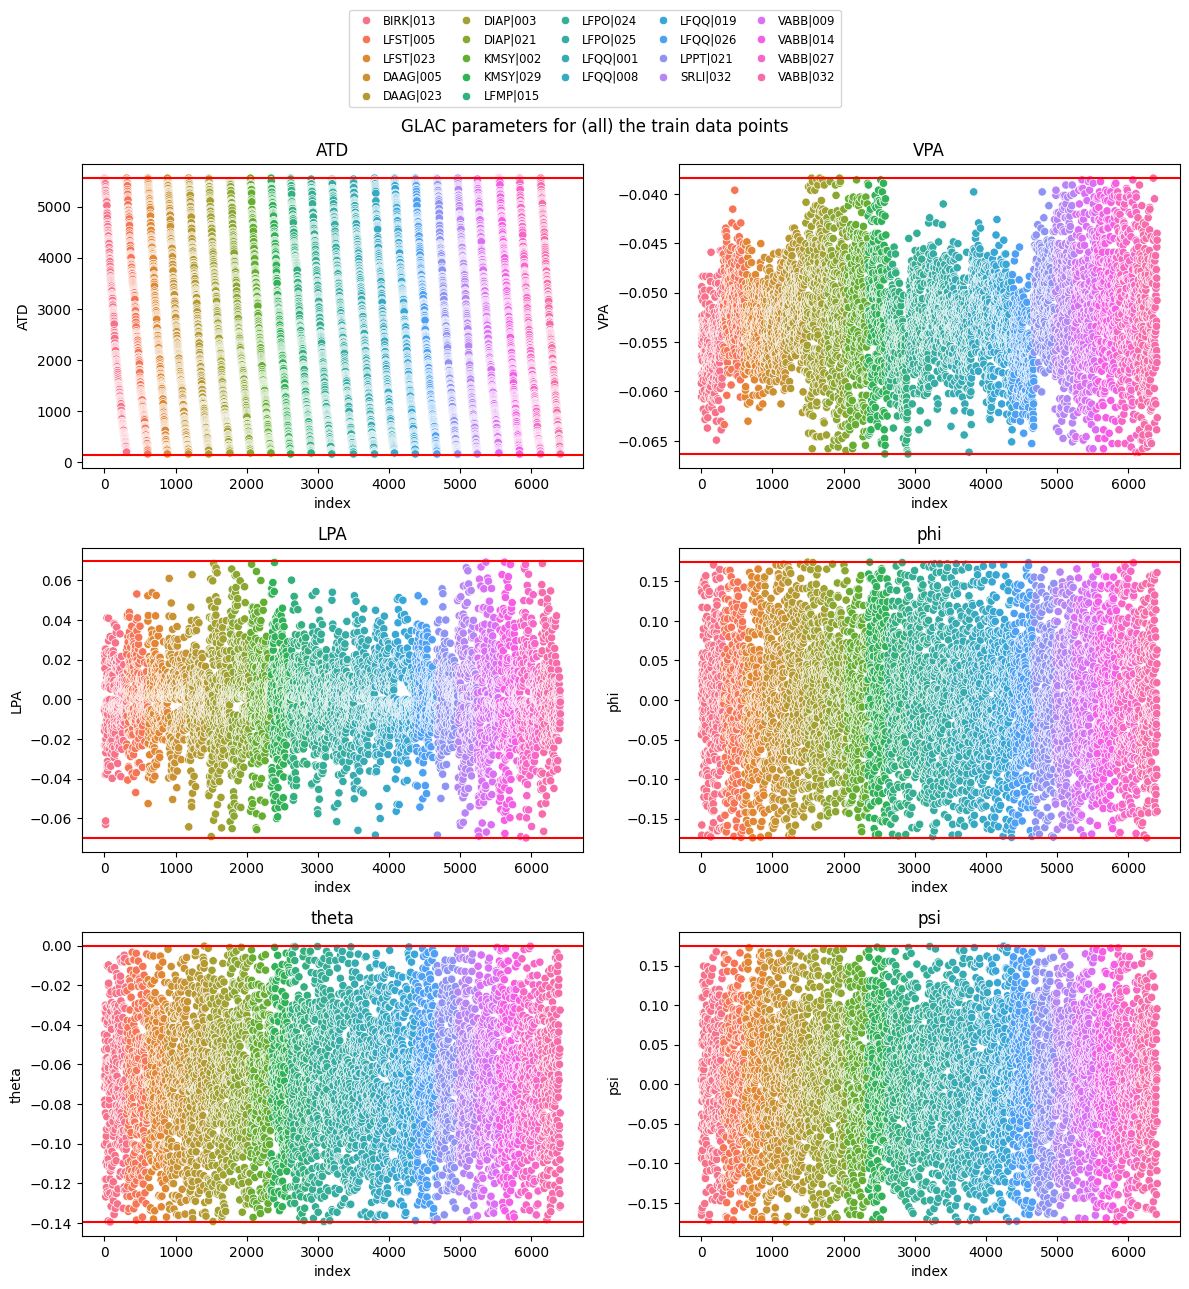

In [61]:
train_df = pd.DataFrame(train_m, columns=METADATA_NAMES).astype(METADATA_TYPES).reset_index()

### All train data ###
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    sns.scatterplot(data=train_df, x='index', y=METADATA_NAMES[i+NB_COLS_TO_SKIP], ax=ax, hue="rnwy_id", legend=(i==0))
    ax.axhline(y=GLAC_SI[METADATA_NAMES[i+NB_COLS_TO_SKIP]][0], color='r')
    ax.axhline(y=GLAC_SI[METADATA_NAMES[i+NB_COLS_TO_SKIP]][1], color='r')
    ax.set_title(METADATA_NAMES[i+NB_COLS_TO_SKIP])

# Adjust the legend placement
handles, labels = axs[0].get_legend_handles_labels()
axs[0].get_legend().remove()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0+0.015*(len(labels)//5+1)),
    ncol=5,  # Number of columns in the legend
    fontsize='small',   # Optional: Reduce font size
    handletextpad=0.5,  # Optional: adjust spacing between handle and text
    columnspacing=1.0,  # Optional: adjust spacing between columns
)

plt.suptitle("GLAC parameters for (all) the train data points")
plt.tight_layout()
plt.show()
######################

<div style="text-align: justify", class="alert alert-info">

**Analysis (for full LARD data)**

We notice the presence of out-of-ODD instances (ODD violations). These are due to several reasons.

First, regarding the first paramater of the *generic landing approach cone* (along track distance), we note that for each runway, many data points are far from the maximum allowed distance (~5500m). Probably for a robust training with respect to tiny ground truths, images of very far runways were added to the training data.

Second, the generation of images in LARD being random acccording to normal distributions (or other types of distributions), it is not guaranteed that **all** instances will fall inside the GLAC boundaries.. Yet the vast majority follows the given boundaries.
</div>

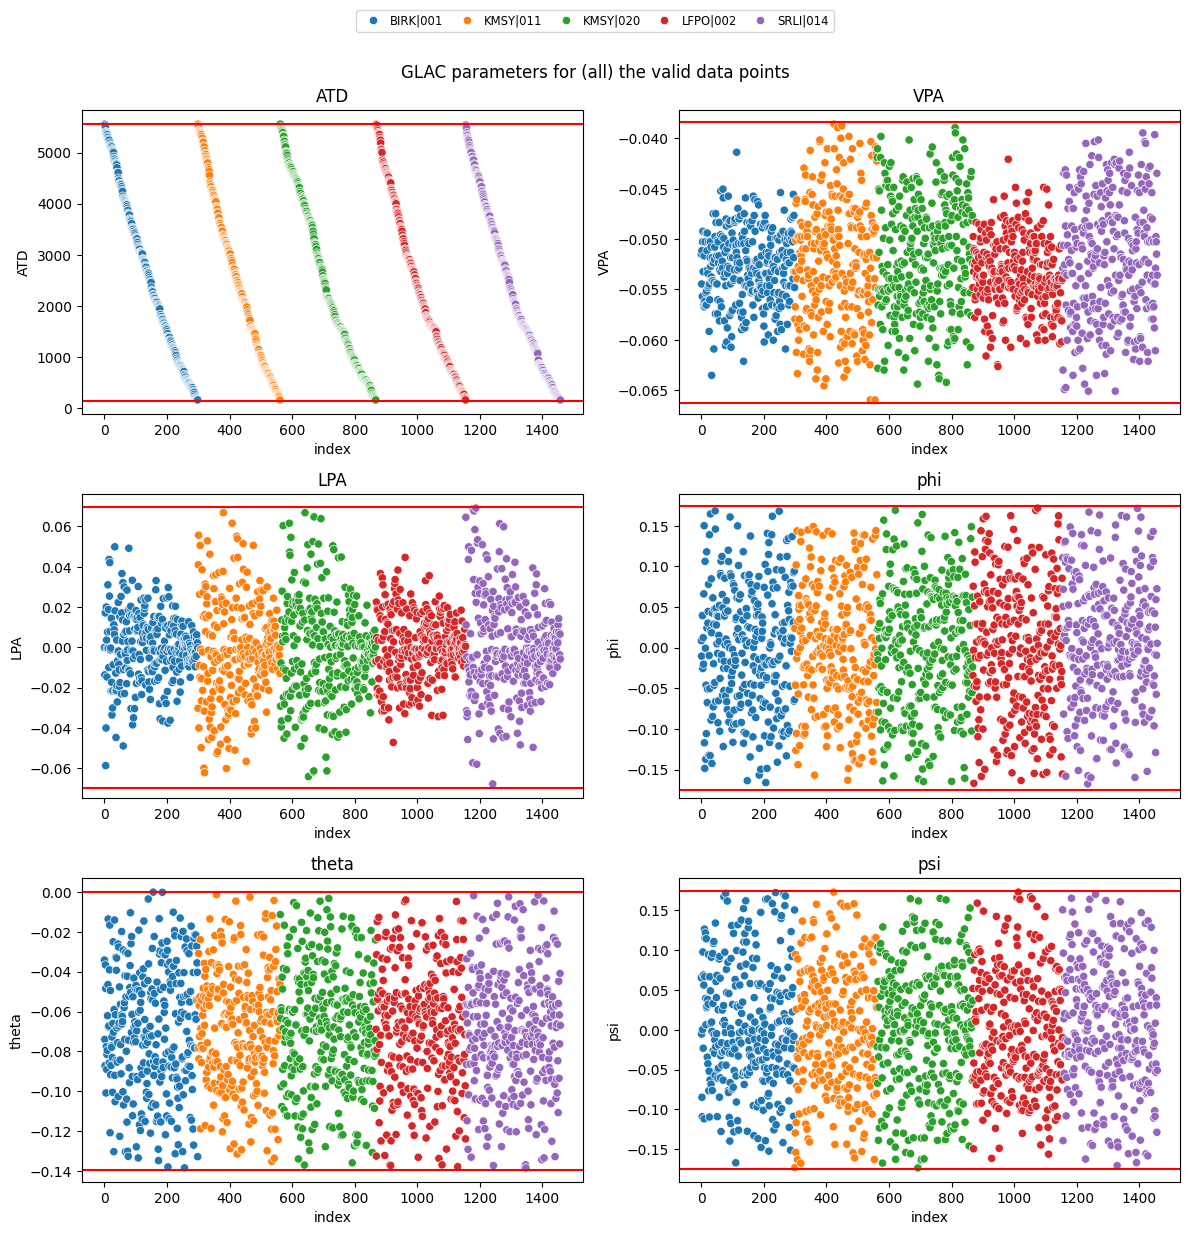

In [62]:
valid_df = pd.DataFrame(valid_m, columns=METADATA_NAMES).astype(METADATA_TYPES).reset_index()

### All valid data ###
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    sns.scatterplot(data=valid_df, x='index', y=METADATA_NAMES[i+NB_COLS_TO_SKIP], ax=ax, hue="rnwy_id", legend=(i==0))
    ax.axhline(y=GLAC_SI[METADATA_NAMES[i+NB_COLS_TO_SKIP]][0], color='r')
    ax.axhline(y=GLAC_SI[METADATA_NAMES[i+NB_COLS_TO_SKIP]][1], color='r')
    ax.set_title(METADATA_NAMES[i+NB_COLS_TO_SKIP])

# Adjust the legend placement
handles, labels = axs[0].get_legend_handles_labels()
axs[0].get_legend().remove()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0+0.015*(len(labels)//5+1)),
    ncol=5,  # Number of columns in the legend
    fontsize='small',   # Optional: Reduce font size
    handletextpad=0.5,  # Optional: adjust spacing between handle and text
    columnspacing=1.0,  # Optional: adjust spacing between columns
)

plt.suptitle("GLAC parameters for (all) the valid data points")
plt.tight_layout()
plt.show()
######################

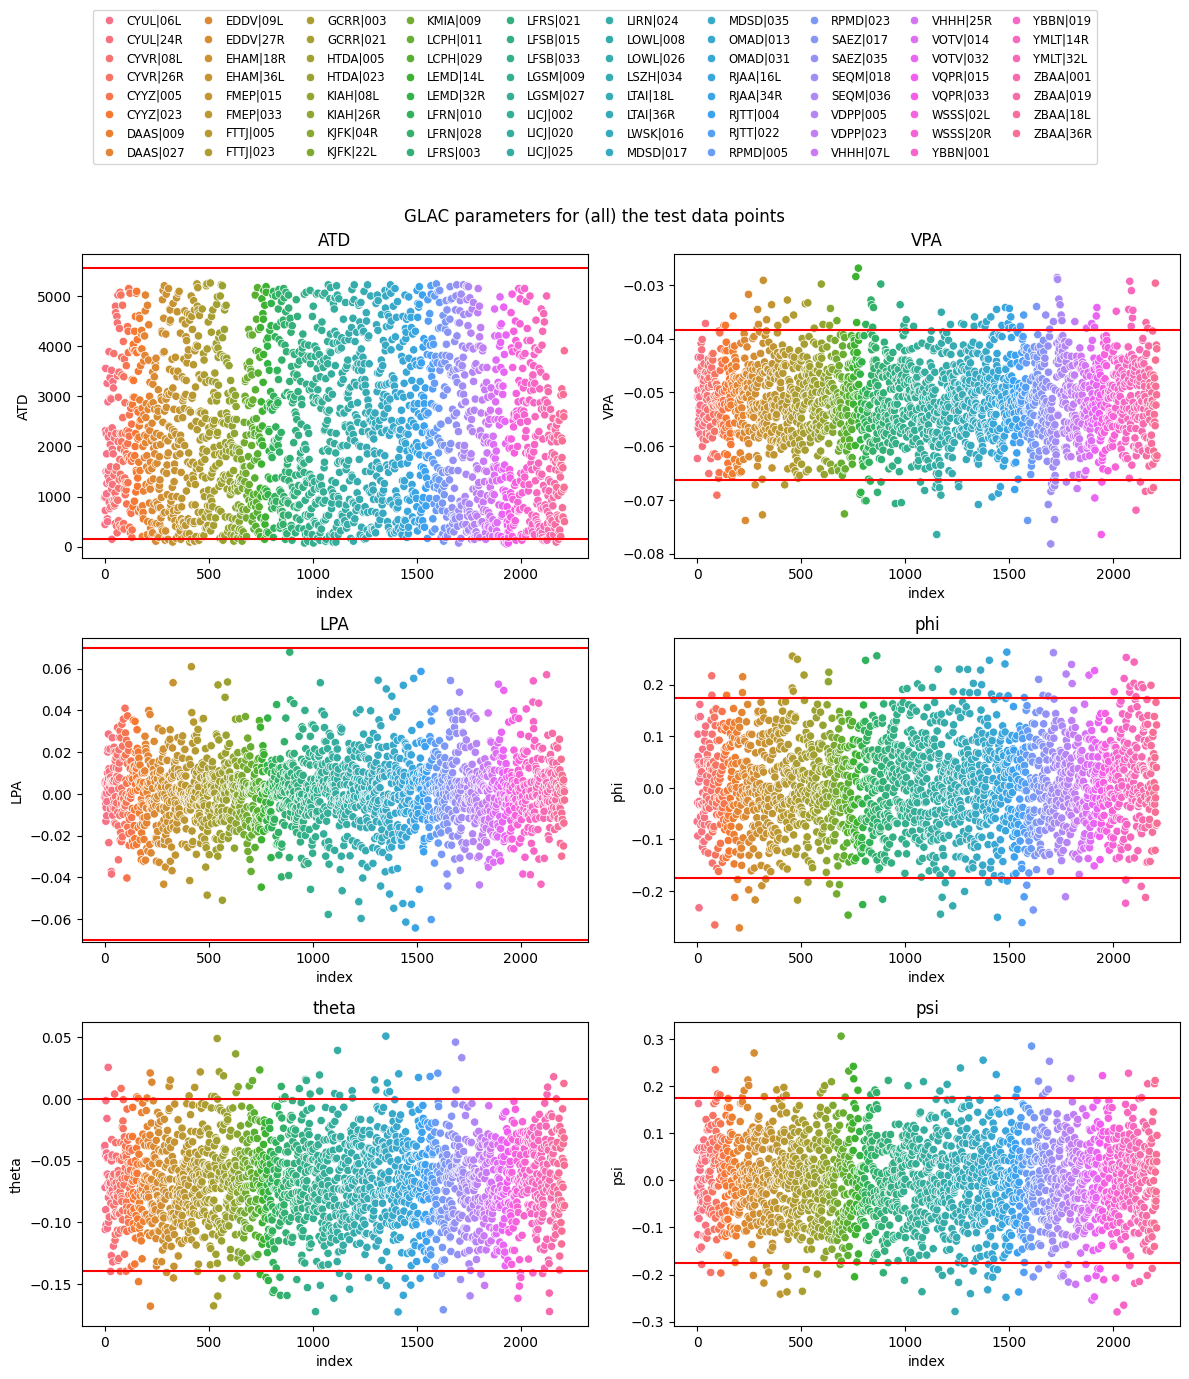

In [63]:
test_df = pd.DataFrame(test_m, columns=METADATA_NAMES).astype(METADATA_TYPES).sort_values(by="rnwy_id").reset_index(drop=True).reset_index()

### All test data ###
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    sns.scatterplot(data=test_df, x='index', y=METADATA_NAMES[i+NB_COLS_TO_SKIP], ax=ax, hue="rnwy_id", legend=(i==0))
    ax.axhline(y=GLAC_SI[METADATA_NAMES[i+NB_COLS_TO_SKIP]][0], color='r')
    ax.axhline(y=GLAC_SI[METADATA_NAMES[i+NB_COLS_TO_SKIP]][1], color='r')
    ax.set_title(METADATA_NAMES[i+NB_COLS_TO_SKIP])

# Adjust the legend placement
handles, labels = axs[0].get_legend_handles_labels()
axs[0].get_legend().remove()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=10,  # Number of columns in the legend
    fontsize='small',   # Optional: Reduce font size
    handletextpad=0.5,  # Optional: adjust spacing between handle and text
    columnspacing=1.0,  # Optional: adjust spacing between columns
)

plt.suptitle("GLAC parameters for (all) the test data points")
plt.tight_layout()
plt.show()
######################

<div style="text-align: justify", class="alert alert-info">

**Remark**

Here again, some landing records are completely off regarding the $\psi$ angle...
</div>

## From GLAC to pixels

<div style="text-align:justify", class="alert alert-danger">

Reflection in this section was not finished

</div>

<div style='text-align: justify'>

In this section, we attempt at projecting the *Generic Landing Approach Cone* (GLAC) into the image pixel coordinate system *(u, v)*. The idea is to get an envelope of the plausible (i.e., correct) pixel coordinates of the runway aiming point.

To do so, we have access to the following information:

- The image resolution in pixel² (W x H) = (2448 x 2648)
- The aircraft's position:
    - `ATD` (along track distance), always positive; 
    - `VPA` negative (according to the LARD paper);
    - `LPA` negative if aircraft on the left of the centerline, positive otherwise 
- The aircraft's attitude ($\phi$, $\theta$, $\psi$) angles

In order to compute the projection of the runway aiming point (*AP*) in the image pixel coordinates, we need both:

- an **extrinsic matrix** $E$ (4x4) that combines a *rotation matrix* $R$ and a *translation vector* $t$ to transform a point coordinate from the world coordinate system (centered on the runway) to the camera coordinate system (centered on the camera) ;

- an **intrinsic matrix** $K$ (3x3) that projects a 3D point in the camera coordinate system into the 2D projection in the image pixel coordinate system. It depends on the camera *focal length* (from *Field of View*, FOV) and the *principal point*. As we do not have such info on the camera characteristics, we will have to estimate the matrix $K$ from known examples in the training data points.
</div>

### Theoretical grounds

#### The extrinsic rotation matrix

##### 1. Rotation around the X-axis

The roll angle ($\phi$) rotates the camera around the **X-axis**. The X-axis corresponds to the axis parallele to the runway centerline. The rotation matrix for roll is:

$$
R_x(\phi) =
\begin{bmatrix}
1 & 0 & 0 \\
0 & \cos(\phi) & -\sin(\phi) \\
0 & \sin(\phi) & \cos(\phi)
\end{bmatrix}
$$

- This matrix leaves the **X-coordinate** unchanged.
- The **Y** and **Z** coordinates are rotated by the roll angle $\phi$.

##### 2. Rotation Around the Y-axis (Pitch)

The pitch angle ($\theta$) rotates the camera around the **Y-axis**. The Y-axis corresponds to the second axis of the horizontal plane, going to the right of the aircraft. The rotation matrix for pitch is:

$$
R_y(\theta) =
\begin{bmatrix}
\cos(\theta) & 0 & \sin(\theta) \\
0 & 1 & 0 \\
-\sin(\theta) & 0 & \cos(\theta)
\end{bmatrix}
$$

- This matrix leaves the **Y-coordinate** unchanged.
- The **X** and **Z** coordinates are rotated by the pitch angle $\theta$.

##### 3. Rotation Around the Z-axis (Yaw)

The yaw angle ($\psi$) rotates the camera around the **Z-axis**. The Z-axis corresponds to the axis perpendicular to the horizontal plane, facing downward. The rotation matrix for yaw is:

$$
R_z(\psi) =
\begin{bmatrix}
\cos(\psi) & -\sin(\psi) & 0 \\
\sin(\psi) & \cos(\psi) & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

- This matrix leaves the **Z-coordinate** unchanged.
- The **X** and **Y** coordinates are rotated by the yaw angle $\psi$.

##### 4. Overall rotation matrix

The overall rotation matrix $ R $ is obtained by multiplying the individual rotation matrices in the order: **yaw**, **pitch**, and **roll**. This is because the rotations are applied in the **intrinsic ZYX order** (yaw around Z, pitch around Y, roll around X):

$$
R = R_z(\psi) \cdot R_y(\theta) \cdot R_x(\phi)
$$

The combined rotation matrix $ R $ is:

$$
R =
\begin{bmatrix}
\cos(\psi)\cos(\theta) & \cos(\psi)\sin(\theta)\sin(\phi) - \sin(\psi)\cos(\phi) & \cos(\psi)\sin(\theta)\cos(\phi) + \sin(\psi)\sin(\phi) \\
\sin(\psi)\cos(\theta) & \sin(\psi)\sin(\theta)\sin(\phi) + \cos(\psi)\cos(\phi) & \sin(\psi)\sin(\theta)\cos(\phi) - \cos(\psi)\sin(\phi) \\
-\sin(\theta) & \cos(\theta)\sin(\phi) & \cos(\theta)\cos(\phi)
\end{bmatrix}
$$

#### The extrinsic translation vector

<div style="text-align: justify">

The extrinsic translation vector $t$ represents the position of the runway (origin of the world) in the `camera|camera` coordinates. If $c$ is the camera position in the `runway|runway` coordinates, we have $c = -R^{-1} t \implies t = -R c$.

The position of the camera in the `runway|runway` coordinates is $(x_c, y_c, z_c)$ with:

- The $x$-coordinate representing the distance along the runway centerline. It is negative when the camera (aircraft) is arriving towards the aiming point.
$$
x_c = -\text{ATD}
$$

- The $y$-coordinate representing the lateral displacement of the camera from the runway centerline. It is positive when the camera is on the left of the centerline.
$$
y_c = \text{ATD} \cdot \tan(\text{LPA})
$$

- The $z$-coordinate representing the height above the ground of the camera. It is negative when the camera (aircraft) is above the ground (counter-intuitive)...
$$
z_c = \text{ATD} \cdot \tan(\text{VPA})
$$

### Estimating $E$ and $K$ by hand

In [64]:
def compute_extrinsic_rotation(phi: Union[np.ndarray, float], theta: Union[np.ndarray, float], psi: Union[np.ndarray, float], can_squeeze_dim=True) -> np.ndarray:
    """
    Compute the extrinsic rotation from camera attitude.
    
    Args:
        phi   (Union[np.ndarray, float]): The roll angle (rotation around x-axis)
        theta (Union[np.ndarray, float]): The pitch angle (rotation around y-axis)
        psi   (Union[np.ndarray, float]): The yaw angle (rotation around z-axis)
    """
    # Convert to np.ndarrays for uniform handling
    phi   = np.asarray(phi)
    theta = np.asarray(theta)
    psi   = np.asarray(psi)

    if not (phi.shape[0] == theta.shape[0] == psi.shape[0]):
        raise ValueError("All provided inputs should have same shapes")
    
    if phi.ndim == 0:
        phi = phi[None]
        psi = psi[None]
        theta = theta[None]

    # Number of input sets
    n = phi.shape[0]

    # Init the output rotation matrix
    R = np.empty((n, 3, 3))

    for i in range(n):
        # Extract individual angles for sample i
        phi_i = phi[i]
        theta_i = theta[i]
        psi_i = psi[i]

        # Rotation around X-axis (phi)
        R_x = np.array([
            [1,             0,              0],
            [0, np.cos(phi_i), -np.sin(phi_i)],
            [0, np.sin(phi_i),  np.cos(phi_i)]
        ])

        # Rotation around Y-axis (theta)
        R_y = np.array([
            [ np.cos(theta_i), 0, np.sin(theta_i)],
            [               0, 1,               0],
            [-np.sin(theta_i), 0, np.cos(theta_i)]
        ])

        # Rotation around Z-axis (psi)
        R_z = np.array([
            [np.cos(psi_i), -np.sin(psi_i), 0],
            [np.sin(psi_i),  np.cos(psi_i), 0],
            [            0,              0, 1]
        ])

        R[i] = R_z @ R_y @ R_x
    
    # If only one input set, squeeze output matrix
    if n == 1 and can_squeeze_dim:
        return R.squeeze(0)
    else:
        return R


def compute_extrinsic_translation(ATD: Union[np.ndarray, float], VPA: Union[np.ndarray, float], LPA: Union[np.ndarray, float], can_squeeze_dim=True) -> np.ndarray:
    """
    Compute the extrinsic translation. 

    Note: 
        The function does not exactly compute the translation vector as directly used in 
        the extrinsic matrix but rather the runway position in the camera|runway coordinates.
    
    Args:
        ATD (Union[np.ndarray, float])
        VPA (Union[np.ndarray, float])
        LPA (Union[np.ndarray, float])
    """
    # Convert scalar inputs to arrays for uniform handling
    ATD = np.asarray(ATD)
    VPA = np.asarray(VPA)
    LPA = np.asarray(LPA)

    if not (ATD.shape[0] == VPA.shape[0] == LPA.shape[0]):
        raise ValueError("All provided inputs should have same shapes")
    
    # Check if inputs are scalar or arrays
    if ATD.ndim == 0:
        ATD = ATD[None]  # Convert to 1D array
        VPA = VPA[None]
        LPA = LPA[None]
    
    n = ATD.shape[0]
    t = np.zeros((n, 3))

    for i in range(n):
        # Get individual parameters
        atd_i = ATD[i]
        vpa_i = VPA[i]
        lpa_i = LPA[i]

        # Compute translation vector
        t[i] = [
            +atd_i,
            -atd_i * np.tan(lpa_i),
            -atd_i * np.tan(vpa_i)
        ]
    
    # Squeeze output if only one input set
    if n == 1 and can_squeeze_dim:
        return t.squeeze(axis=0)
    else:
        return t


def compute_extrinsic_matrix(
        ATD: Union[np.ndarray, float],
        VPA: Union[np.ndarray, float],
        LPA: Union[np.ndarray, float],
        phi: Union[np.ndarray, float],
        theta: Union[np.ndarray, float],
        psi: Union[np.ndarray, float],
        can_squeeze_dim=True,
) -> np.ndarray:
    """
    Compute the extrinsic matrix from camera position & attitude.

    Args:
        ATD   (Union[np.ndarray, float]): The along-track distance.
        VPA   (Union[np.ndarray, float]): The vertical path angle.
        LPA   (Union[np.ndarray, float]): The lateral path angle.
        phi   (Union[np.ndarray, float]): The roll angle.
        theta (Union[np.ndarray, float]): The pitch angle.
        psi   (Union[np.ndarray, float]): The yaw angle.
    """
    # Convert to arrays
    ATD   = np.asarray(ATD)
    VPA   = np.asarray(VPA)
    LPA   = np.asarray(LPA)
    phi   = np.asarray(phi)
    theta = np.asarray(theta)
    psi   = np.asarray(psi)

    if not (ATD.shape == VPA.shape == LPA.shape == phi.shape == theta.shape == psi.shape):
        raise ValueError("All provided inputs should have same shapes")
    
    if ATD.ndim == 0:
        ATD = ATD[None]  # Convert to 1D array
        VPA = VPA[None]
        LPA = LPA[None]
        phi = phi[None]
        theta = theta[None]
        psi = psi[None]    
    n = ATD.shape[0]
    
    # Compute the rotation and translation
    R = compute_extrinsic_rotation(phi, theta, psi, can_squeeze_dim=False)
    c = compute_extrinsic_translation(ATD, VPA, LPA, can_squeeze_dim=False)

    # Compute real translation vector
    t = np.matvec(-R, c)

    # Combine the components
    E = np.empty((n, 4, 4))
    E[:, :3, :3] = R
    E[:, :3,  3] = t
    E[:,  3, :3] = 0
    E[:,  3,  3] = 1

    if n == 1 and can_squeeze_dim:
        return E.squeeze(0)
    else:
        return E

<div style='text-align: justify', class="alert alert-warning">

Verify that the extrinsic computation is `OK`.
</div>

In [65]:
### DEBUG ###
m = train_df.iloc[[0,1]]

r = compute_extrinsic_rotation(m.phi, m.theta, m.psi)
c = compute_extrinsic_translation(m.ATD, m.VPA, m.LPA)
t1 = np.matvec(-r, c)
print(f"Translation vector (by t1=-R@c)\nt={t1}")

e = compute_extrinsic_matrix(m.ATD, m.VPA, m.LPA, m.phi, m.theta, m.psi)
p = np.array([0, 0, 0, 1])
t2 = np.matvec(e, p)[:,:3]
print(f"Translation vector (by t2= E@p)\nt={t2}")

assert np.all(np.equal(t1, t2)), "ERROR"
#############

Translation vector (by t1=-R@c)
t=[[-5494.61949931   -74.72308196  -884.26737189]
 [-5492.71501307   388.6793403   -661.33993219]]
Translation vector (by t2= E@p)
t=[[-5494.61949931   -74.72308196  -884.26737189]
 [-5492.71501307   388.6793403   -661.33993219]]


In [66]:
def estimate_intrinsic_matrix(
        ATD: np.ndarray,
        VPA: np.ndarray,
        LPA: np.ndarray,
        phi: np.ndarray,
        theta: np.ndarray,
        psi: np.ndarray,
        segmsk: np.ndarray,
        img_w: int,
        img_h: int,
):
    """
    Estimate the intrinsic matrix from a batch of data points.

    Args:
        ATD   (np.ndarray, [N,]): Batch of ATD
        VPA   (np.ndarray, [N,]): Batch of VPA
        LPA   (np.ndarray, [N,]): Batch of LPA
        phi   (np.ndarray, [N,]): Batch of phi
        theta (np.ndarray, [N,]): Batch of theta
        psi   (np.ndarray, [N,]): batch of psi
        segmsk (np.ndarray, [N, 8]): Batch of segmentation checkpoints (xA,yA,xB,...,xD,yD)
        img_w (int): The common images width
        img_h (int): The common images height
    """
    if not (ATD.shape == VPA.shape == LPA.shape == phi.shape == theta.shape == psi.shape):
        raise ValueError("All provided inputs should have same dimension")

    # Number of inputs    
    N = ATD.shape[0]

    if N != segmsk.shape[0]:
        raise ValueError("All provided inputs should have same dimension")

    # Compute the extrinsic matrices
    E = compute_extrinsic_matrix(ATD, VPA, LPA, phi, theta, psi)  # Should be (N, 4, 4)

    # Compute the position of the middle of the piano in the camera|camera coords system
    P_w = np.array([-300, 0, 0, 1])  # Homogenous coords of the middle of piano (NOT aiming point)
    P_c = np.matvec(E, P_w)          # (N, 4)

    # Compute the troncated coordinates
    xz = P_c[:, 0] / P_c[:, 2]
    yz = P_c[:, 1] / P_c[:, 2]

    # Fill in the A matrix
    A = np.zeros((2*N, 4))
    A[N:, 0] = xz
    A[N:, 1] = 1
    A[:N, 2] = yz
    A[:N, 3] = 1

    # Fill in the B vector
    u = (segmsk[:, 4] + segmsk[:, 6]) / 2. * img_w  # Find the pixel coord of the middle of piano
    v = (segmsk[:, 5] + segmsk[:, 7]) / 2. * img_h  # as the middle of bottom segmsk points
    b = np.concatenate((u, v))

    # Resolve the equation
    p, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

    # Extract individual coefficients
    fx, cx, fy, cy = p

    # Construct the intrinsic matrix
    K = np.array([
        [fx,  0, cx],
        [ 0, fy, cy],
        [ 0,  0,  1],
    ])

    return K

Estimate the intrinsic matrix from a batch of N images.

In [67]:
# Train dataset (segment)
train_y_seg = np.empty((0, *ML_LABEL_SHAPE["segment"]))
for _, y in tqdm.tqdm(train_seg_dataloader):
    train_y_seg = np.concatenate([train_y_seg, np.stack(y, axis=0)], axis=0)
train_y_seg.shape

# Temp fix 
train_y_seg = train_y_seg.squeeze(1)
train_y_seg.shape

  0%|          | 0/101 [00:00<?, ?it/s]

100%|██████████| 101/101 [00:12<00:00,  8.35it/s]


(6410, 9)

In [68]:
### EDIT HERE ###
SEED = 42
np.random.seed(SEED)
#################

### EDIT HERE ###
N_IMG = 50
#################

IMG_W = 512
IMG_H = 512
n_img = np.random.permutation(train_m.shape[0])[N_IMG]

# Get the camera positions
c_positions = train_m[:n_img, 3:6].astype(float)
# Get the camera attitudes
c_attitudes = train_m[:n_img, 6:9].astype(float)
# Get the runway marker points
r_markers = train_y_seg[:n_img, 1:]

print("Camera positions", c_positions.shape)
print("Camera attitudes", c_attitudes.shape)
print("Runway markers  ", r_markers.shape)

# Estimate K
K = estimate_intrinsic_matrix(*c_positions.T, *c_attitudes.T, r_markers, IMG_W, IMG_H)
K

# N = 100
# K = array([
#     [  1.9682283 ,   0.        , 231.82574401],
#     [  0.        , -18.04920054, 243.68959894],
#     [  0.        ,   0.        ,   1.        ]])

Camera positions (247, 3)
Camera attitudes (247, 3)
Runway markers   (247, 8)


array([[  9.31339446,   0.        , 163.07093645],
       [  0.        , -57.814821  , 258.12217861],
       [  0.        ,   0.        ,   1.        ]])

<div style="text-align: justify", class="alert alert-danger">

**Warning**

Given the results below (super-imposition of image and projected middle of the piano), it seems the projection does not work very well... Need to explore deeper to find the problem. So far, we cannot use the GLAC projection for monitoring...

Ideas to dig:
- Using `opencv` builtin methods to estimate $E$ and $K$ directly from images.
- Using a different $K$ for each landing record (there might be different focals involved across the records...)
</div>

### Estimating $E$ and $K$ with `opencv`

### Projection

In [69]:
def project_3D_point_to_2D_pixel(
    ATD: Union[np.ndarray, float],
    VPA: Union[np.ndarray, float],
    LPA: Union[np.ndarray, float],
    phi: Union[np.ndarray, float],
    theta: Union[np.ndarray, float],
    psi: Union[np.ndarray, float],
    K: np.ndarray,   
    can_squeeze_dim=True     
):
    """
    Project 3D point(s) (in runway|runway coordinates) into 2D pixel coord system.

    Args:
        ATD   (Union[np.ndarray, float]):
        VPA   (Union[np.ndarray, float]):
        LPA   (Union[np.ndarray, float]):
        phi   (Union[np.ndarray, float]):
        theta (Union[np.ndarray, float]):
        psi   (Union[np.ndarray, float]):
        K     (np.ndarray):
        can_squeeze_dim (bool): True if function can squeeze a dim out if only 1 sample.
    """
    # Convert to arrays
    ATD   = np.asarray(ATD)
    VPA   = np.asarray(VPA)
    LPA   = np.asarray(LPA)
    phi   = np.asarray(phi)
    theta = np.asarray(theta)
    psi   = np.asarray(psi)

    if not (ATD.shape == VPA.shape == LPA.shape == phi.shape == theta.shape == psi.shape):
        raise ValueError("All provided inputs should have same dimension")
    
    if ATD.ndim == 0:
        ATD = ATD[None]  # Convert to 1D array
        VPA = VPA[None]
        LPA = LPA[None]
        phi = phi[None]
        theta = theta[None]
        psi = psi[None] 
    n = ATD.shape[0]    
    
    # Compute extrinsic matrix
    E = compute_extrinsic_matrix(ATD, VPA, LPA, phi, theta, psi, can_squeeze_dim=False)

    # Project
    P_w = np.array([0, 0, 0, 1])
    P_c = np.matvec(E, P_w)[:,:3]
    P_p = np.matvec(K, P_c)

    # Extract pixels coords
    uv = P_p[:, 0:2] / P_p[:, 2]

    # Squeeze output if only one dim
    if n == 1 and can_squeeze_dim:
        return uv.squeeze(0)
    else:  
        return uv

Visualize the projection...

In [70]:
SEED = 42
np.random.seed(42)

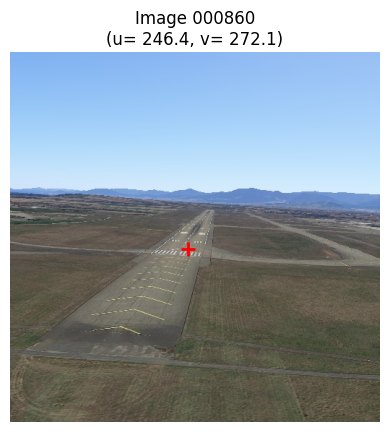

In [71]:
# Get back the train dataset
train_dataset = train_dataloader.dataset

# Select the data
image_i = np.random.randint(0, len(train_dataset))  # Show a random image 
X, y, m = train_dataset[image_i]

# Get the metadata
c_pos = m[3:6].astype(float)
c_att = m[6:9].astype(float)

# Project onto pixels
u, v = project_3D_point_to_2D_pixel(*c_pos, *c_att, K)

# Show image & projection
plt.scatter(u, v, color="r", marker="+", s=100, linewidths=2)
plt.imshow(X.permute(1,2,0))
plt.title(f"Image {image_i:06d}\n(u={u:>6.1f}, v={v:>6.1f})")
plt.axis('off')
plt.show()
